Corps massif  m1 = 0.9091  →  x1 = -0.09091
Corps léger   m2 = 0.0909  →  x2 = 0.90909
Vérif CDM : 0.00e+00 (≈ 0 ✓)


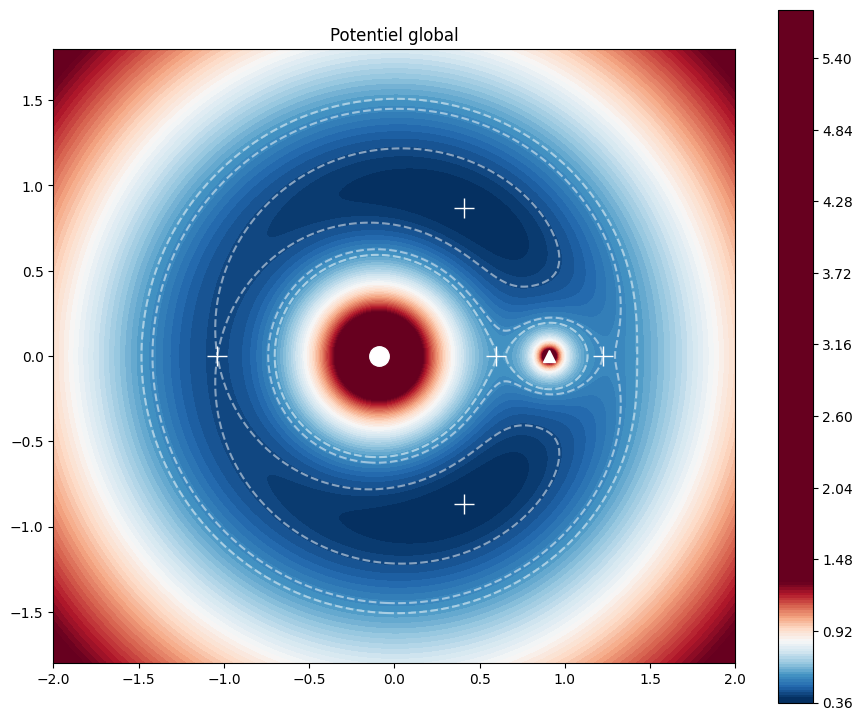

In [1]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import brentq

# ══════════════════════════════════════════════════════════════════
#  Paramètres normalisés
# ══════════════════════════════════════════════════════════════════
mu = 1.0 / 11.0

x1 = -mu
x2 = 1.0 - mu

print(f"Corps massif  m1 = {1-mu:.4f}  →  x1 = {x1:.5f}")
print(f"Corps léger   m2 = {mu:.4f}  →  x2 = {x2:.5f}")
print(f"Vérif CDM : {(1-mu)*x1 + mu*x2:.2e} (≈ 0 ✓)")

# ══════════════════════════════════════════════════════════════════
#  Potentiel effectif
# ══════════════════════════════════════════════════════════════════
def U_eff(x, y):
    r1 = np.sqrt((x - x1)**2 + y**2)
    r2 = np.sqrt((x - x2)**2 + y**2)
    r1 = np.maximum(r1, 1e-5)
    r2 = np.maximum(r2, 1e-5)
    return -(1.0 - mu) / r1 - mu / r2 - 0.5 * (x**2 + y**2)

# ══════════════════════════════════════════════════════════════════
#  Grille globale
# ══════════════════════════════════════════════════════════════════
N = 800
xg = np.linspace(-2.0, 2.0, N)
yg = np.linspace(-1.8, 1.8, N)
X, Y = np.meshgrid(xg, yg)
U = U_eff(X, Y)

U_log = np.log(-U)
vmin = np.percentile(U_log, 2)
vmax = np.percentile(U_log, 98)

# ══════════════════════════════════════════════════════════════════
#  Points de Lagrange
# ══════════════════════════════════════════════════════════════════
r_H = (mu / 3.0) ** (1.0 / 3.0)

L1x = x2 - r_H
L2x = x2 + r_H
L3x = -1.0 - 5.0 * mu / 12.0

lagrange = {
    'L1': (L1x, 0.0),
    'L2': (L2x, 0.0),
    'L3': (L3x, 0.0),
    'L4': (0.5 - mu, np.sqrt(3)/2),
    'L5': (0.5 - mu, -np.sqrt(3)/2),
}

# ══════════════════════════════════════════════════════════════════
#  PLOT GLOBAL (INCHANGÉ)
# ══════════════════════════════════════════════════════════════════
fig, ax = plt.subplots(figsize=(11, 9))

cf = ax.contourf(X, Y, U_log, levels=300, cmap='RdBu_r',
                 vmin=vmin, vmax=vmax)

plt.colorbar(cf, ax=ax)

lagrange_U = sorted({U_eff(lx, ly) for lx, ly in lagrange.values()})
ax.contour(X, Y, U, levels=lagrange_U,
           colors='white', linestyles='--', alpha=0.5)

ax.plot(x1, 0, 'wo', ms=14)
ax.plot(x2, 0, 'w^', ms=9)

for name, (lx, ly) in lagrange.items():
    ax.plot(lx, ly, 'w+', ms=14)

ax.set_xlim(-2, 2)
ax.set_ylim(-1.8, 1.8)
ax.set_aspect('equal')

ax.set_title("Potentiel global")
plt.show()



v0 = 0.1945274291
x range: -8.450652433978526 9.487019144741106
y range: -7.486020822863689 9.388066776618823

Aucune divergence detectee — augmenter tmax ou reduire dist_convergence.


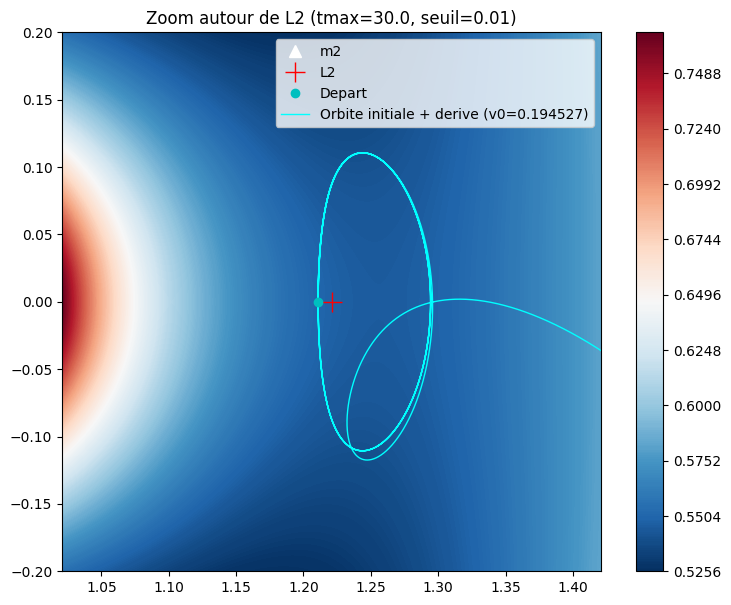

In [16]:

from scipy.optimize import fsolve

# ══════════════════════════════════════════════════════════════════
#  DYNAMIQUE CR3BP
# ══════════════════════════════════════════════════════════════════
def acceleration(x, y, vx, vy):
    r1 = np.sqrt((x - x1)**2 + y**2)
    r2 = np.sqrt((x - x2)**2 + y**2)
    r1 = max(r1, 1e-8)
    r2 = max(r2, 1e-8)
    ax = x - (1-mu)*(x - x1)/r1**3 - mu*(x - x2)/r2**3 + 2*vy
    ay = y - (1-mu)*y/r1**3 - mu*y/r2**3 - 2*vx
    return ax, ay


def rk4_step(state, dt):
    def f(s):
        x, y, vx, vy = s
        ax, ay = acceleration(x, y, vx, vy)
        return np.array([vx, vy, ax, ay])
    k1 = f(state)
    k2 = f(state + 0.5 * dt * k1)
    k3 = f(state + 0.5 * dt * k2)
    k4 = f(state + dt * k3)
    return state + (dt/6.0)*(k1 + 2*k2 + 2*k3 + k4)


def simulate(v0, x0, dt=1e-4, tmax=30):
    """Depart propre : (x0, y=0, vx=0, vy=v0). Retourne vx au 1er retour en y=0."""
    state = np.array([x0, 0.0, 0.0, v0])
    y_prev, vx_prev = 0.0, 0.0
    t = 0
    while t < tmax:
        state = rk4_step(state, dt)
        x, y, vx, vy = state
        if y_prev > 0 and y < 0:
            frac = y_prev / (y_prev - y)
            return vx_prev + frac * (vx - vx_prev)
        y_prev = y
        vx_prev = vx
        t += dt
    return None


def find_v0(x0):
    """Trouve vy tel que vx=0 au retour en y=0. Suppose depart en (x0, y=0, vx=0)."""
    def f(v0):
        val = simulate(v0, x0)
        return 1e3 if val is None else val
    return brentq(f, 0.01, 1.0, xtol=1e-12, rtol=1e-12, maxiter=200)


def simulate_to_y0(vx0, vy0, x_start, y_start, dt=1e-4, tmax=30):
    """
    Integre depuis un point arbitraire (x_start, y_start) jusqu'au
    premier passage en y=0. Retourne (vx, x) interpoles a la traversee.
    """
    state = np.array([x_start, y_start, vx0, vy0])
    y_prev = y_start
    left_zero = abs(y_start) > 1e-6
    t = 0
    while t < tmax:
        state_prev = state.copy()
        state = rk4_step(state, dt)
        x, y, vx, vy = state

        if not left_zero and abs(y) > 1e-6:
            left_zero = True

        if left_zero and y_prev * y < 0:
            frac     = abs(y_prev) / (abs(y_prev) + abs(y))
            x_cross  = state_prev[0] + frac * (x  - state_prev[0])
            vx_cross = state_prev[2] + frac * (vx - state_prev[2])
            return vx_cross, x_cross

        y_prev = y
        t += dt
    return None, None


def find_v0_new(x_start, y_start, vx_div, vy_div,
                dt=1e-4, tmax_short=5.0, n_grid=30, delta=0.15):
    """
    Recherche sur grille 2D autour de (vx_div, vy_div).
    Pour chaque couple (vx, vy) :
      - simule avec limite tmax_short (si pas de retour rapide en y=0 -> rejete)
      - conserve le couple minimisant |vx| au passage en y=0
    Puis affine avec brentq 1D sur vy autour du meilleur couple.
    """
    vx_vals = np.linspace(vx_div - delta, vx_div + delta, n_grid)
    vy_vals = np.linspace(vy_div - delta, vy_div + delta, n_grid)

    best_abs_vx = np.inf
    best_vx     = vx_div
    best_vy     = vy_div

    # Phase 1 : scan grossier
    for vx0 in vx_vals:
        for vy0 in vy_vals:
            vx_cross, _ = simulate_to_y0(vx0, vy0, x_start, y_start, dt, tmax_short)
            if vx_cross is not None and abs(vx_cross) < best_abs_vx:
                best_abs_vx = abs(vx_cross)
                best_vx     = vx0
                best_vy     = vy0

    # Phase 2 : affinage brentq sur vy (vx fixe)
    step = vy_vals[1] - vy_vals[0]

    def residual_vy(vy0):
        vx_cross, _ = simulate_to_y0(best_vx, vy0, x_start, y_start, dt, tmax_short)
        return 1e3 if vx_cross is None else vx_cross

    vy_fine = np.linspace(best_vy - step, best_vy + step, 20)
    vals    = np.array([residual_vy(v) for v in vy_fine])
    vy_sol  = best_vy
    for k in range(len(vals) - 1):
        if abs(vals[k]) < 500 and abs(vals[k+1]) < 500 and vals[k] * vals[k+1] < 0:
            vy_sol = brentq(residual_vy, vy_fine[k], vy_fine[k+1],
                            xtol=1e-12, rtol=1e-12, maxiter=200)
            break

    return best_vx, vy_sol


def trajectory(x0, y0, vx0, vy0, dt, tmax, dist_convergence=0.01):
    """
    Boucle unique :
      - Phase 1 : enregistre ref_orbit pendant la 1ere periode.
      - Phase 2 : compare a ref_orbit[phase_idx % period_len] a chaque pas.
      - Des que dist > dist_convergence : sauvegarde state_at_divergence (une seule fois),
        puis CONTINUE jusqu'a tmax pour montrer la derive complete.

    Retourne : (traj, state_at_divergence, t_divergence)
    """
    state = np.array([x0, y0, vx0, vy0])
    steps = int(tmax / dt)
    traj  = np.empty((steps + 1, 4))
    traj[0] = state

    ref_orbit  = [state.copy()]
    demi_orbit = False
    one_orbit  = False
    period_len = 0
    phase_idx  = 0

    state_at_divergence = None
    t_divergence        = None

    for i in range(steps):
        state       = rk4_step(state, dt)
        traj[i + 1] = state
        time        = (i + 1) * dt

        y_prev = traj[i][1]
        y_curr = traj[i + 1][1]

        if not one_orbit:
            ref_orbit.append(state.copy())
            if (y_curr < 0 and y_prev > 0) or (y_curr > 0 and y_prev < 0):
                if not demi_orbit:
                    demi_orbit = True
                else:
                    one_orbit  = True
                    period_len = len(ref_orbit) - 1
                    ref_orbit  = np.array(ref_orbit)
        else:
            if state_at_divergence is None:
                phase_idx += 1
                ref_pos  = ref_orbit[phase_idx % period_len, :2]
                curr_pos = state[:2]
                dist     = np.sqrt((curr_pos[0] - ref_pos[0])**2 + (curr_pos[1] - ref_pos[1])**2)
                if dist > dist_convergence:
                    state_at_divergence = state.copy()
                    t_divergence        = time

    return traj[:i+2], state_at_divergence, t_divergence


# ══════════════════════════════════════════════════════════════════
#  PARAMETRES DU RUN
# ══════════════════════════════════════════════════════════════════
x0               = L2x - 0.01
dt               = 1e-4
tmax             = 30.0
dist_convergence = 0.01
zoom             = 0.2

# ══════════════════════════════════════════════════════════════════
#  CALCUL trajectoire bleue
# ══════════════════════════════════════════════════════════════════
v0 = find_v0(x0)
print(f"\nv0 = {v0:.10f}")

traj, state_div, t_div = trajectory(
    x0, 0.0, 0.0, v0, dt, tmax, dist_convergence=dist_convergence
)

print("x range:", traj[:,0].min(), traj[:,0].max())
print("y range:", traj[:,1].min(), traj[:,1].max())

# ══════════════════════════════════════════════════════════════════
#  CORRECTION trajectoire verte
# ══════════════════════════════════════════════════════════════════
state_div = None
traj2 = None

if state_div is not None:
    print(f"\nDivergence a t = {t_div:.4f}")
    print(f"  etat : x={state_div[0]:.6f}, y={state_div[1]:.6f}, vx={state_div[2]:.6f}, vy={state_div[3]:.6f}")

    vx_new, vy_new = find_v0_new(
        state_div[0], state_div[1],
        state_div[2], state_div[3],
        dt=dt
    )
    print(f"  vx_new={vx_new:.8f}, vy_new={vy_new:.8f}")

    tmax_corr = tmax - t_div
    traj2, _, _ = trajectory(
        state_div[0], state_div[1], vx_new, vy_new,
        dt, tmax_corr, dist_convergence=dist_convergence
    )
else:
    print("\nAucune divergence detectee — augmenter tmax ou reduire dist_convergence.")

# ══════════════════════════════════════════════════════════════════
#  PLOT ZOOME sur L2
# ══════════════════════════════════════════════════════════════════
xg = np.linspace(L2x - zoom, L2x + zoom, 400)
yg = np.linspace(-zoom, zoom, 400)
Xz, Yz = np.meshgrid(xg, yg)
Uz_log = np.log(-U_eff(Xz, Yz))

fig2, ax2 = plt.subplots(figsize=(9, 7))
cf = ax2.contourf(Xz, Yz, Uz_log, levels=300, cmap='RdBu_r')
plt.colorbar(cf, ax=ax2)

ax2.plot(x2,  0, 'w^', ms=9,  label='m2')
ax2.plot(L2x, 0, 'r+', ms=14, label='L2')
ax2.plot(x0,  0, 'co', ms=6,  zorder=5, label='Depart')

ax2.plot(traj[:,0], traj[:,1], 'cyan', lw=1,
         label=f'Orbite initiale + derive (v0={v0:.6f})')

if traj2 is not None:
    ax2.plot(traj2[:,0], traj2[:,1], 'lime', lw=1.5,
             label=f'Orbite corrigee (t_div={t_div:.2f})')
    ax2.plot(state_div[0], state_div[1], 'yo', ms=10, zorder=6, label='Point de correction')

ax2.set_xlim(L2x - zoom, L2x + zoom)
ax2.set_ylim(-zoom, zoom)
ax2.set_aspect('equal')
ax2.set_title(f"Zoom autour de L2 (tmax={tmax}, seuil={dist_convergence})")
ax2.legend()
plt.show()
